In [1]:
import pandas as pd

Load the dataset and display:

First 5 rows  
Shape  
Column types  

In [2]:
df = pd.read_csv(r"C:\Users\91987\Downloads\Class 2-20260513T015243Z-3-001\Class 2\m3w1s3_grocery_store_data.csv")
df.head()

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32


In [3]:
df.shape

(25000, 6)

In [4]:
df.dtypes

Customer_ID             int64
Store_ID               object
Transaction_Amount    float64
Basket_Size             int64
Visit_Day              object
Customer_Age            int64
dtype: object

Check:

Missing values  
Unique values in Store_ID and Visit_Day  

In [5]:
print(df.isnull())

       Customer_ID  Store_ID  Transaction_Amount  Basket_Size  Visit_Day  \
0            False     False               False        False      False   
1            False     False               False        False      False   
2            False     False               False        False      False   
3            False     False               False        False      False   
4            False     False               False        False      False   
...            ...       ...                 ...          ...        ...   
24995        False     False               False        False      False   
24996        False     False               False        False      False   
24997        False     False               False        False      False   
24998        False     False               False        False      False   
24999        False     False               False        False      False   

       Customer_Age  
0             False  
1             False  
2             False  

In [6]:
print(df['Store_ID'].unique())
print(df['Visit_Day'].unique())

['S001' 'S004' 'S002' 'S003']
['Thu' 'Fri' 'Sun' 'Tue' 'Wed' 'Sat' 'Mon']


Find the mean Transaction Amount

In [7]:
df['Transaction_Amount'].mean()

np.float64(75.02023080000001)

Find mean Transaction Amount:

Per Store_ID   
Per Visit_Day  

In [8]:
print(df.groupby('Store_ID')['Transaction_Amount'].mean().reset_index().rename(columns = {'Transaction_Amount':'Average_Transaction_Amount'}))

  Store_ID  Average_Transaction_Amount
0     S001                   75.191684
1     S002                   75.257383
2     S003                   74.627236
3     S004                   75.003663


In [9]:
print(df.groupby('Visit_Day')['Transaction_Amount'].mean().reset_index().rename(columns = {'Transaction_Amount':'Average_Transaction_Amount'}))

  Visit_Day  Average_Transaction_Amount
0       Fri                   74.905804
1       Mon                   74.847254
2       Sat                   75.678271
3       Sun                   74.391620
4       Thu                   75.115612
5       Tue                   75.220323
6       Wed                   74.980282


Which store has the highest average transaction value?

In [10]:
df.groupby('Store_ID')['Transaction_Amount'].mean().sort_values(ascending= False).head(1)

Store_ID
S002    75.257383
Name: Transaction_Amount, dtype: float64

If one transaction = ₹1,00,000 is added:  

What happens to mean?

In [11]:
new_row = {
    'Customer_ID' : 99999,
    'Store_ID' : 'S002',
    'Transaction_Amount' : 100000,
    'Basket_Size' : 4,
    'Visit_Day' :'Sat',
    'Customer_Age' : 48 
}

In [12]:
df_new = pd.DataFrame([new_row])

In [13]:
df_new = pd.concat([df,df_new])

In [14]:
df_new['Transaction_Amount'].mean()

np.float64(79.01707011719532)

Find median Transaction Amount

In [15]:
df['Transaction_Amount'].median()

75.06

In [16]:
df['Transaction_Amount'].mean()

np.float64(75.02023080000001)

Compare:

Mean vs Median of Transaction Amount
What does the difference indicate?

there copuld be more outliers but they are not so strong.which means they would be close by and they are not making much diffrence.

Find median Basket_Size per Store_ID

In [17]:
df.groupby('Store_ID')['Basket_Size'].median()

Store_ID
S001    5.0
S002    5.0
S003    5.0
S004    5.0
Name: Basket_Size, dtype: float64

Find:

Most common Visit_Day
Most common Basket_Size

In [18]:
df['Visit_Day'].mode()

0    Mon
Name: Visit_Day, dtype: object

In [19]:
df['Basket_Size'].mode()

0    4
Name: Basket_Size, dtype: int64

Find mode of Store_ID → Which store gets most visits?

In [20]:
df['Store_ID'].mode()

0    S002
Name: Store_ID, dtype: object

Plot boxplot of Transaction_Amount

Text(0.5, 1.0, 'Transaction Amount')

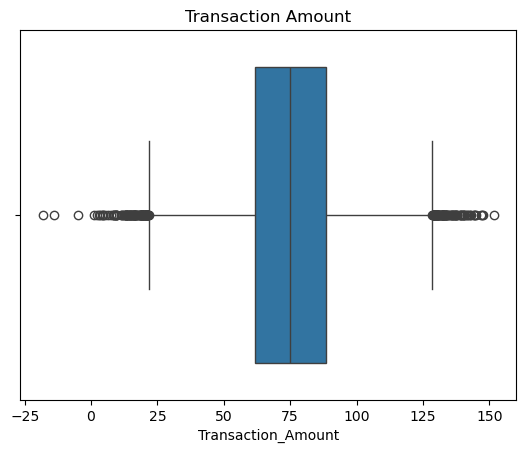

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x = 'Transaction_Amount', data = df)
plt.title('Transaction Amount')

Identify outliers using:  

IQR method

In [22]:
q1 = df['Transaction_Amount'].quantile(0.25)
q3 = df['Transaction_Amount'].quantile(0.75)
iqr = q3 - q1
lower_fence = q1-1.5*(iqr)
upper_fence = q3 +1.5*(iqr)
outliers = df[(df['Transaction_Amount']<lower_fence )| (df['Transaction_Amount']<upper_fence)]
outliers

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32
...,...,...,...,...,...,...
24995,24996,S004,102.24,6,Mon,45
24996,24997,S001,47.09,5,Mon,23
24997,24998,S003,72.37,5,Tue,38
24998,24999,S004,66.39,5,Thu,32


Remove outliers and recompute:

Mean  
Median  

In [23]:
clean_df = df[(df['Transaction_Amount']>=lower_fence) & (df['Transaction_Amount']<=upper_fence)]

In [24]:
clean_df

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32
...,...,...,...,...,...,...
24995,24996,S004,102.24,6,Mon,45
24996,24997,S001,47.09,5,Mon,23
24997,24998,S003,72.37,5,Tue,38
24998,24999,S004,66.39,5,Thu,32


In [25]:
clean_df['Transaction_Amount'].mean()

np.float64(75.04479814478725)

In [26]:
clean_df['Transaction_Amount'].median()

75.07

Range=Max−Min

Q16

Find range of:

Transaction_Amount
Customer_Age

In [27]:
range_ta = df['Transaction_Amount'].max() - df['Transaction_Amount'].min()
range_ta

169.83999999999997

In [28]:
range_ca = df['Customer_Age'].max() - df['Customer_Age'].min()
range_ca

51

Which variable is more spread out?

In [29]:
df.std(numeric_only=True)

Customer_ID           7217.022701
Transaction_Amount      19.977965
Basket_Size              2.249787
Customer_Age            15.064971
dtype: float64

In [30]:
df.std(numeric_only=True).sort_values(ascending=False)

Customer_ID           7217.022701
Transaction_Amount      19.977965
Customer_Age            15.064971
Basket_Size              2.249787
dtype: float64

Why is range unreliable for this dataset?

Range considers only max and min values. However std. Deviation considers distance of each value form the mean . Hence std. Deviation is the better measure to find out how reliable the dataset is.

Concept: Spread using squared deviations (page 29)

Q19

Compute variance of:

Transaction_Amount
Customer_Age

In [31]:
df['Transaction_Amount'].var()

399.11906916949516

In [32]:
df['Customer_Age'].var()

226.95334488420193

Which feature is more volatile?

Transaction Amount is the column which has greater variance which means it is more volatile.

Compare std deviation across stores

In [33]:
df.groupby('Store_ID')['Transaction_Amount'].std()

Store_ID
S001    19.894279
S002    20.292766
S003    19.777187
S004    19.940429
Name: Transaction_Amount, dtype: float64

CV=
μ/σ
	


Q27

Compute CV for:

Transaction_Amount

COV for each store id

Histogram of Transaction_Amount

<Axes: xlabel='Transaction_Amount', ylabel='Count'>

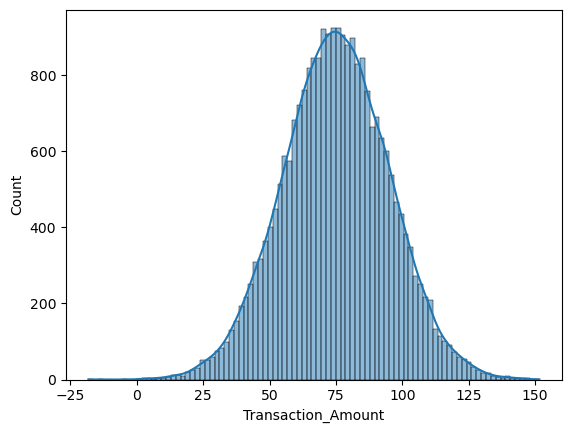

In [34]:
sns.histplot(df['Transaction_Amount'],kde= True)

Boxplot of Transaction_Amount per Store

<Axes: xlabel='Store_ID', ylabel='Transaction_Amount'>

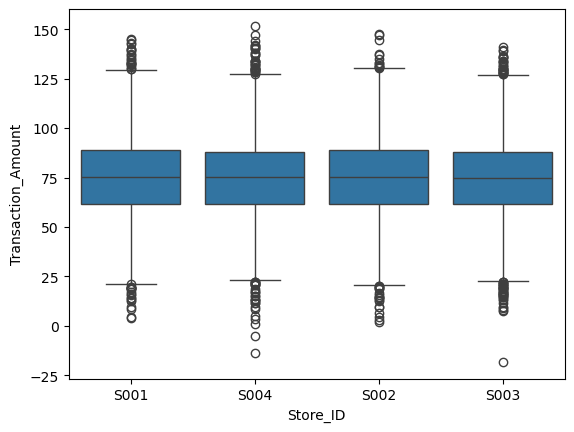

In [35]:
sns.boxplot(x = 'Store_ID', y = 'Transaction_Amount', data = df)

Should the company use:

Mean or Median to define "average customer spend"?

when there is not much huge difference between mean and median you can go ahead with mean, but median is always a safe bet.

Which day has:

Highest spending customers?

In [36]:
df.groupby('Visit_Day')['Transaction_Amount'].sum().sort_values(ascending= False).head(1)

Visit_Day
Mon    276336.06
Name: Transaction_Amount, dtype: float64

Which store:

Has consistent customers (low variance)?

In [37]:
df.groupby('Store_ID')['Transaction_Amount'].var().sort_values().head(1)

Store_ID
S003    391.137114
Name: Transaction_Amount, dtype: float64